[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DebbieJara/connectatel-analysis/blob/main/Project_ConnectaTel.ipynb)

# Análisis Exploratorio de Datos — ConnectaTel

Este proyecto analiza el comportamiento de clientes de **ConnectaTel**, empresa de telecomunicaciones latinoamericana, a partir de datos registrados hasta 2024.

El análisis cubre tres datasets:
- **plans.csv** — información de los planes disponibles (precios, minutos, GB incluidos)
- **users_latam.csv** — datos demográficos y de plan de los clientes
- **usage.csv** — registros de uso real (llamadas y mensajes)

A través de exploración, limpieza y segmentación de datos, se identificaron patrones de consumo, comportamientos atípicos y segmentos de clientes con el objetivo de optimizar la oferta comercial de la empresa.


## 1. Carga y Exploración Inicial
### 1.1 Carga de datos
Se importan las librerías necesarias y se cargan los tres datasets para una revisión preliminar de su estructura, tipos de datos y contenido.


In [3]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# cargar archivos
plans = pd.read_csv('https://raw.githubusercontent.com/DebbieJara/connectatel-analysis/main/datasets/plans.csv')
users = pd.read_csv('https://raw.githubusercontent.com/DebbieJara/connectatel-analysis/main/datasets/users_latam.csv')
usage = pd.read_csv('https://raw.githubusercontent.com/DebbieJara/connectatel-analysis/main/datasets/usage.csv')

In [5]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Estructura de los datasets
Se revisan los tipos de datos, dimensiones y primeras observaciones de cada dataset.


In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


## 2. Calidad de Datos
### 2.1 Valores nulos
Se identifican y cuantifican los valores faltantes en cada dataset para evaluar su impacto en el análisis.


In [12]:
# cantidad de nulos para users
print('Cantidad de nulos:')
print(users.isna().sum())
print('\nPorcentaje de nulos:')
print((users.isna().mean() * 100).round(2))


Cantidad de nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Porcentaje de nulos:
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [13]:
# cantidad de nulos para usage
print('Cantidad de nulos:')
print(usage.isna().sum())
print('\nPorcentaje de nulos:')
print((usage.isna().mean() * 100).round(2))

Cantidad de nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Porcentaje de nulos:
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


### 2.2 Valores inválidos y sentinels
Se identifican valores que no deberían estar en el dataset, revisando columnas numéricas y categóricas en busca de sentinels y anomalías.


In [14]:
# explorar columnas numéricas de users
print('Cantidad de user_ids únicos:', users['user_id'].nunique())
print('Total de registros:', len(users))

Cantidad de user_ids únicos: 4000
Total de registros: 4000


In [15]:
print(users['age'].describe())

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [16]:
print('Valores únicos de age:')
print (sorted(users['age'].unique()))

Valores únicos de age:
[np.int64(-999), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79)]


In [17]:
valor_sentinel = -999
print(f"Registros con valor sentinel: {(users['age'] == valor_sentinel).sum()}")

Registros con valor sentinel: 55


- La columna `user_id` contiene el mismo número de registros que IDs únicos (no hay duplicados).
- La columna `age` tiene cinco registros con un valor sentinel (-999).

In [18]:
print('Cantidad de ids únicos:', usage['id'].nunique())
print('Total de registros', len(usage))

Cantidad de ids únicos: 40000
Total de registros 40000


In [19]:
print('Cantidad de user_ids:', usage['user_id'].nunique())
print('Total de registros', len(usage))

Cantidad de user_ids: 3999
Total de registros 40000


In [20]:
print(usage['user_id'].describe())

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64


In [21]:
print('Análisis de duration:')
print(usage['duration'].describe())
print("\nAnálisis de length:")
print(usage['length'].describe())

Análisis de duration:
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

Análisis de length:
count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64


In [22]:
print('Porcentaje de nulos en duration :')
print((usage['duration'].isna().mean() * 100).round(2))
print('\nPorcentaje de nulos en length:')
print((usage['length'].isna().mean() * 100).round(2))


Porcentaje de nulos en duration :
55.19

Porcentaje de nulos en length:
44.74


- Las columnas `id` y `user_id` muestran comportamientos diferentes. La columna 'id' no tiene duplicados, funcionando como clave primaria. La columna 'user_id' sí tiene duplicados (3999 únicos en 40,000 registros) indicando que cada usuario tiene múltiples registros de uso.
- Las columnas 'duration' y 'length' muestran un patrón de nulos estructural (55.19% y 44.74% respectivamente). Esto sugiere que los valores faltantes dependen del tipo de evento ('type') donde las llamadas tendrán duration, pero no length y viceversa.

In [23]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


In [24]:
print('Valores únicos en city:')
print (users['city'].unique())

Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [25]:
# Contar valores nulos
nulos_city = users['city'].isnull().sum()
print(f'Valores NaN en city: {nulos_city}')

Valores NaN en city: 469


In [26]:
# Contar valores sentinel
sentinels_city = (users['city'] == '?').sum()
print(f"Valores sentinel '?' en city: {sentinels_city}")

Valores sentinel '?' en city: 96


In [27]:
# Total de datos faltantes
total_faltantes = nulos_city + sentinels_city
total_registros = len(users)
porcentaje_faltantes = (total_faltantes / total_registros) * 100

print(f"Total datos faltantes en city: {total_faltantes}")
print(f"Porcentaje: {porcentaje_faltantes:.2f}%")

Total datos faltantes en city: 565
Porcentaje: 14.12%


In [28]:
print(f"Diagnóstico completo de city:")
print(f"- Valores nulos originales: {nulos_city}")
print(f"- Valores sentinel '?': {sentinels_city}")
print(f"- Total datos faltantes: {total_faltantes} ({porcentaje_faltantes:.2f}%)")
print(f"- Acción: Reemplazar '?' por NaN para estandarizar")

Diagnóstico completo de city:
- Valores nulos originales: 469
- Valores sentinel '?': 96
- Total datos faltantes: 565 (14.12%)
- Acción: Reemplazar '?' por NaN para estandarizar


In [29]:
print('Valores únicos en plan:')
print(users['plan'].unique())

Valores únicos en plan:
['Basico' 'Premium']


- La columna `city` muestra 7 valores únicos incluyendo 1 valor sentinel "?" y valores ausentes (nan). Las ciudades válidas son: Medellín, CDMX, Bogotá, GDL, MTY, Cali. Esto sugiere problemas de calidad de datos que requieren limpieza.

- La columna `plan` muestra consistencia con solo 2 categorías válidas: 'básico' y 'premium', sin valores problemáticos detectados.

In [30]:
# explorar columna categórica de usage
usage['type']
print('Valores únicos en type:')
print(usage['type'].unique())

Valores únicos en type:
['call' 'text']


- La columna `type` muestra consistencia con solo 2 categorías válidas: 'call' y 'text', sin valores problemáticos detectados.


### 2.3 Revisión de fechas
Se convierten las columnas de fecha al tipo correcto y se identifican fechas fuera del rango esperado (posteriores a 2024).


In [31]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [32]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [33]:
# Revisar los años presentes en `reg_date` de users
years_reg_date = users['reg_date'].dt.year.value_counts()
print(years_reg_date)

reg_date
2024    1330
2023    1316
2022    1314
2026      40
Name: count, dtype: int64


In [34]:
total_2026 = (users['reg_date'].dt.year == 2026).sum()
total_registros = len(users)
porcentaje_invalidos = (total_2026 / total_registros) * 100

print(f"Total años inválidos: {total_2026}")
print(f"Porcentaje: {porcentaje_invalidos:.2f}%")

Total años inválidos: 40
Porcentaje: 1.00%


En `reg_date` se observan 40 registros con año 2026 (1% del total), los cuales representan una fecha imposible dado que los registros llegan hasta el 2024.   

In [35]:
# Revisar los años presentes en `date` de usage
years_date = usage['date'].dt.year.value_counts()
print(years_date)

date
2024.0    39950
Name: count, dtype: int64


En `date` se encontró que todos los registros válidos pertenecen al año 2024, lo cual es consistente con el rango esperado de los datos.  
Basaremos el análisis en estas fechas.

## 3. Limpieza de Datos
### 3.1 Corrección de sentinels y fechas imposibles
Se aplican reglas de limpieza: los sentinels en `age` (-999) se reemplazan con la mediana, los `'?'` en `city` se convierten a nulos, y las fechas fuera de rango se marcan como nulas.


In [36]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, pd.NA).median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [37]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
print(users['city'].unique())

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [38]:


# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NaT)

# Verificar cambios
print(users['reg_date'].isna().sum())




40


In [39]:
# Verificar que no quedan fechas futuras
print("Años únicos después de la limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años únicos después de la limpieza:
reg_date
2022.0    1314
2023.0    1316
2024.0    1330
Name: count, dtype: int64


### 3.2 Tratamiento de valores nulos
Se analiza si los nulos en `duration` y `length` responden a un patrón estructural, verificando su relación con la columna `type`. Se confirma que son MNAR — los nulos dependen de la naturaleza del evento (llamada o mensaje) y se mantienen.


In [40]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].count())
print(usage.groupby('type')['duration'].size())

type
call    17908
text       16
Name: duration, dtype: int64
type
call    17908
text    22092
Name: duration, dtype: int64


In [41]:
usage.isna().groupby(usage['type'])['duration'].sum()

,duration
type,
call,0
text,22076


In [42]:
usage['duration'].isna().sum()

np.int64(22076)

In [43]:
resultado = usage.groupby('type')['duration'].agg(lambda x: x.isnull().mean().round(1))
print(resultado)

type
call    0.0
text    1.0
Name: duration, dtype: float64


In [44]:

# Verificación MAR en usage (Missing At Random) para length


In [45]:
resultado = usage.groupby('type')['length'].agg(lambda x: x.isnull().mean().round(1))
print(resultado)

type
call    1.0
text    0.0
Name: length, dtype: float64


Los nulos en `duration` y `length` son MNAR — no son aleatorios sino que dependen de la naturaleza del evento. `duration` solo existe en llamadas y `length` solo en mensajes, por lo que los nulos son estructurales y se dejan como están.


## 4. Estadísticas de Uso por Usuario
### 4.1 Agregación por usuario
Se construye una tabla agregada por `user_id` con métricas de comportamiento: total de mensajes, llamadas y minutos de llamada. Esta tabla se combina con el dataset de usuarios para crear un perfil completo.


In [46]:

# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum','is_call': 'sum','duration': 'sum'}). reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [47]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call': 'cant_llamadas','duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [48]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = user_profile  = usage_agg.merge(users, on='user_id')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 Resumen estadístico
Se analiza la distribución de las variables numéricas clave y la distribución porcentual del tipo de plan entre los usuarios.


In [49]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age,reg_date
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3959
mean,11999.729432,5.524381,4.478120,23.317054,48.138285,2023-07-03 23:11:34.436427776
min,10000.000000,0.000000,0.000000,0.000000,18.000000,2022-01-01 00:00:00
25%,10999.500000,4.000000,3.000000,11.120000,33.000000,2022-10-02 18:38:37.179294720
50%,12000.000000,5.000000,4.000000,19.780000,48.000000,2023-07-04 13:17:14.358589696
75%,12999.500000,7.000000,6.000000,31.415000,63.000000,2024-04-03 05:38:39.879970048
max,13999.000000,17.000000,15.000000,155.690000,79.000000,2024-12-31 00:00:00
std,1154.898108,2.358416,2.144238,18.168095,17.691541,NaN


In [50]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

,proportion
plan,
Basico,64.866217
Premium,35.133783


## 5. Visualización y Detección de Outliers
### 5.1 Distribuciones
Se grafican histogramas para las variables clave (`age`, `cant_mensajes`, `cant_llamadas`, `cant_minutos_llamada`), segmentados por tipo de plan, para identificar patrones de comportamiento.


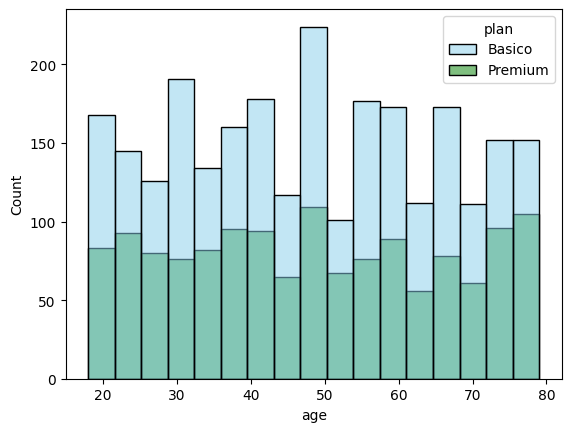

In [51]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.show()


💡Insights:
- La distribución de edad es aproximadamente uniforme entre 20 y 80 años, con un ligero pico alrededor de los 50. Se observa que en el rango de 70 a 80 años hay una mayor proporción de usuarios Premium, lo cual podría indicar que los adultos mayores tienen mayor capacidad económica para costear planes más altos. Este segmento representa una oportunidad para optimizar la oferta comercial dirigida a usuarios de mayor edad, mientras que para usuarios jóvenes, que podrían estar en etapas tempranas de generación de ingresos, podría ser relevante reforzar la propuesta de valor del plan Básico.

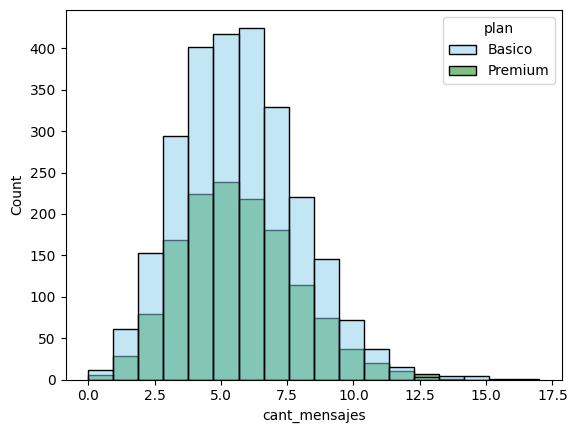

In [52]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=18)
plt.show()

💡Insights:
- La distribución de cant_mensajes es sesgada a la derecha, con la mayoría de usuarios enviando entre 4 y 6 mensajes. Los usuarios Premium se concentran proporcionalmente más en ese rango medio-alto, lo que sugiere que el mayor acceso a datos del plan Premium incentiva un mayor uso de mensajería. Para la empresa, esto representa una oportunidad de promover upgrades a Premium entre usuarios Básico con alto volumen de mensajes, ofreciendo promociones de datos como incentivo.

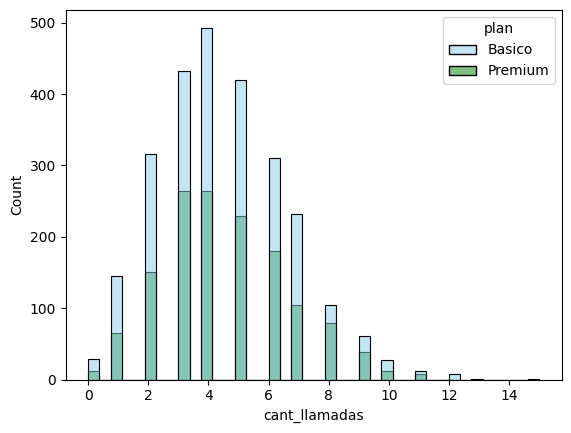

In [53]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan',
palette=['skyblue', 'green'])
plt.show()


💡Insights:
- Distribución sesgada a la derecha. Se observa que os usuarios Premium tienden a realizar más llamadas que los Básico, patrón consistente con el histograma de cant_mensajes. Esto confirma la hipótesis de que los usuarios Premium aprovechan más el servicio por lo que pagan, lo que refuerza la oportunidad de promover upgrades entre usuarios Básico con alto volumen de uso.

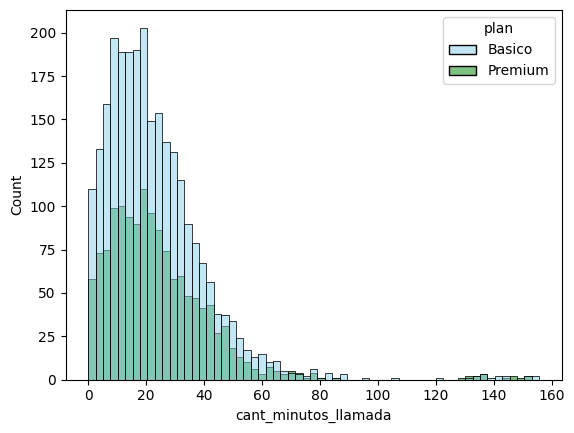

In [54]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada',hue='plan',palette=['skyblue', 'green'])
plt.show()

💡Insights:
- Distribución sesgada a la derecha con mayor concentración alrededor de los 20 minutos. La duración de llamadas es similar entre ambos planes, lo que sugiere que el plan no influye en cuánto tiempo habla un usuario sino en la frecuencia con la que llama. Esto podría indicar que los usuarios Básico están limitados por su plan, lo que refuerza la oportunidad de promover upgrades a Premium.

### 5.2 Identificación de Outliers
Se generan boxplots para detectar valores extremos en las variables clave. Para las columnas con outliers se calculan los límites usando el método IQR y se decide si mantenerlos o eliminarlos.


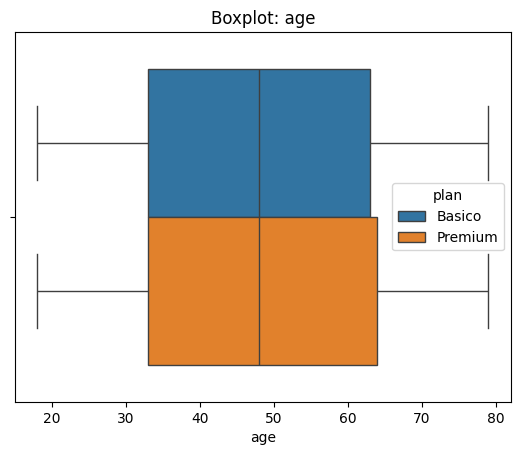

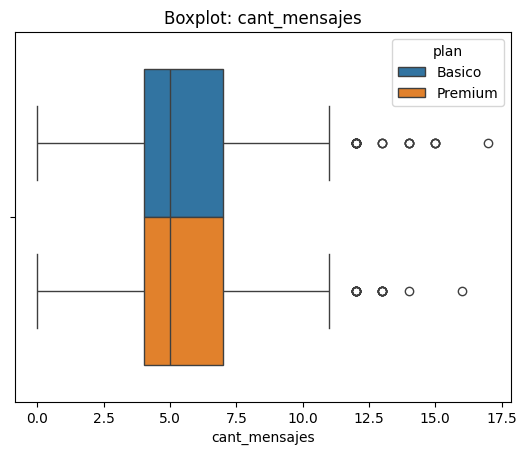

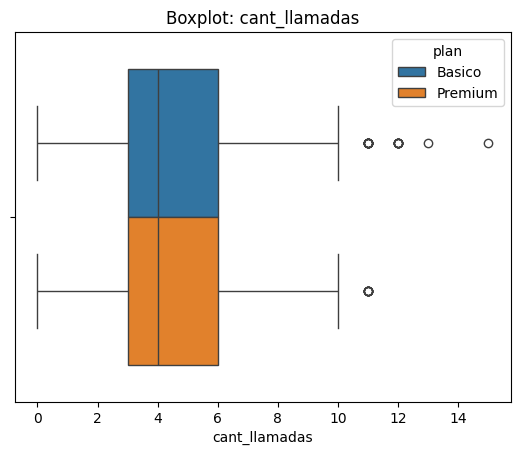

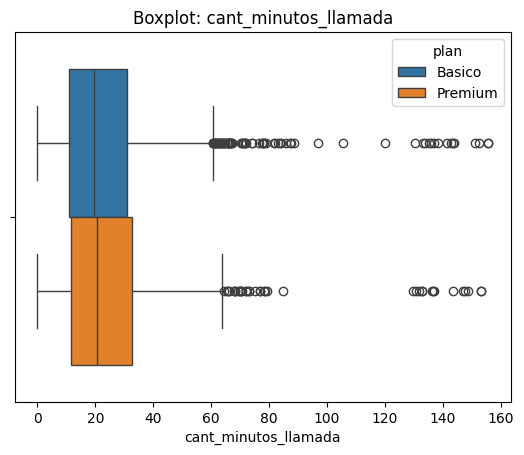

In [55]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, hue='plan')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: Tanto la caja como los bigotes están equilibrados en el rango IQR. No se presentan outliers.
- cant_mensajes: Los bigotes están equilibrados con relación al IQR, con la mediana cargada hacia 5 mensajes. Se observan outliers del lado derecho a partir de ~11 mensajes, representando usuarios que envían una cantidad significativamente alta de mensajes.
- cant_llamadas: La mediana está cargada hacia 4 llamadas con el bigote máximo más largo. Se observan outliers del lado derecho a partir de ~11 llamadas, representando usuarios con uso elevado del servicio.
- cant_minutos_llamada: La mediana se encuentra alrededor de los 20 minutos con el IQR ligeramente sesgado a la izquierda. El bigote máximo llega aproximadamente a los 70 minutos, a partir de donde se observan numerosos outliers representando usuarios con volumen de llamadas significativamente mayor al resto.
- En los tres casos los outliers aparecen únicamente del lado derecho, lo que sugiere un segmento de usuarios con uso alto del servicio que podría representar clientes de alto valor para la empresa.

In [56]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile [col].quantile(0.75)
    IQR = Q3-Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col} - Límite superior: {limite_superior:.2f}")

cant_mensajes - Límite superior: 11.50
cant_llamadas - Límite superior: 10.50
cant_minutos_llamada - Límite superior: 61.86


In [57]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

- cant_mensajes: los outliers se encuentran únicamente de lado máximo comenzando a partir de 11.5 mensajes hasta 17 mensajes en su nivel máximo representando a usuarios que tienen gran uso del servicio de mensajería por lo que se deben mantener.
- cant_llamadas: los outliers comienzan en 10.5 llegando a un máximo de 15 llamadas, rpresentando a usuarios que tienen gran uso del servicio de llamadas por lo que se deben mantener.
- cant_minutos_llamada: los outliers comienzan en 61.86 minutos llegando a un máximo de 155.69 minutos, representando usuarios con un volumen de llamadas significativamente alto. Al ser valores posibles dentro del contexto de telecomunicaciones, se deben mantener.

## 6. Segmentación de Clientes
### 6.1 Segmentación por Nivel de Uso
Se clasifica a cada usuario en tres grupos según su volumen de mensajes y llamadas: Bajo uso, Uso medio y Alto uso.


In [58]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] <5) & (user_profile['cant_mensajes'] <5),
    (user_profile['cant_llamadas'] <10) & (user_profile['cant_mensajes']<10)
]

valores = [
    'Bajo uso',
    'Uso medio'
]

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

In [59]:
user_profile['grupo_uso'].value_counts()

,count
grupo_uso,
Uso medio,2943
Bajo uso,778
Alto uso,278


In [60]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación por Edad
Se clasifica a cada usuario en tres grupos etarios: Joven (menor de 30), Adulto (menor de 60) y Adulto Mayor (60 o más).


In [61]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age'] <30),
    (user_profile['age'] <60)
]

valores = [
    'Joven',
    'Adulto'
]

user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')


In [62]:
user_profile['grupo_edad'].value_counts()

,count
grupo_edad,
Adulto,2017
Adulto Mayor,1222
Joven,760


In [63]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación
Se grafican las distribuciones de `grupo_uso` y `grupo_edad` para visualizar la composición del cliente base de ConnectaTel.


/tmp/ipykernel_7020/3668226250.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_uso',


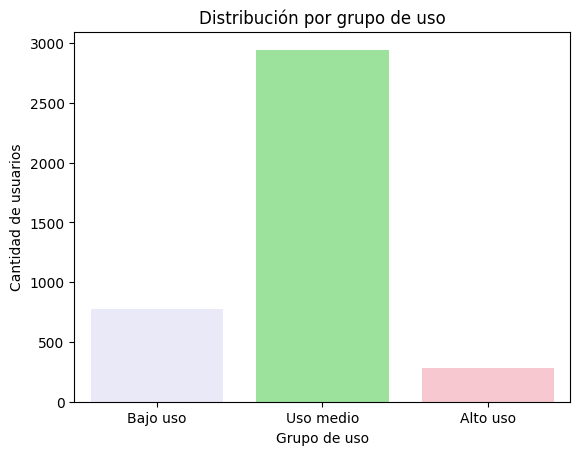

In [64]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso',
              order=['Bajo uso', 'Uso medio', 'Alto uso'],
              palette=['lavender', 'lightgreen', 'pink'])
plt.title('Distribución por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

/tmp/ipykernel_7020/1632030792.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_edad',


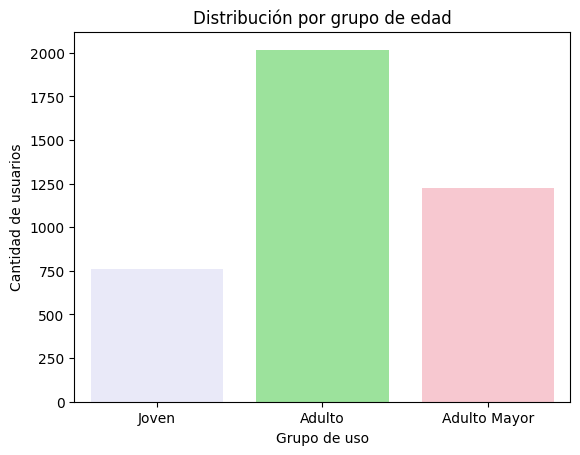

In [65]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',
              order=['Joven', 'Adulto', 'Adulto Mayor'],
              palette=['lavender', 'lightgreen', 'pink'])
plt.title('Distribución por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

## 7. Insight Ejecutivo
Resumen de hallazgos y recomendaciones accionables para ConnectaTel basadas en el análisis exploratorio.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Se encontraron diferentes problemas en dos dataframes. En el dataframe de users, se encontró que 469 de los valores eran nulos (11.72%) y 96 valores eran sentinel ('?'), sumando 565 registros faltantes (14.13%). Se reemplazaron los sentinel por nulos. Así mismo, se encontró que en la columna de 'age' se encontraron 55 registros con valor sentinel -999 (1.37%), mismo que se reemplazaron con la mediana por ser más robusta ante outliers. Finalmente, se encontró que para la columna 'reg_date' habían 40 registros con año 2026 (1%), fecha imposible dado que los datos llegan hasta 2024. Se marcaron como nulos. Por otro lado, para el dataframe de usage se encontró que para la columna 'date' habían 50 registros nulos (0.12%) mismos que se eliminaron por ser un caso mínimo. Finalmente se encontró que en las columnas 'duration' y 'length' había 55.19% y 44.74% de nulos respectivamente. Dado que dichos nulos dependen del tipo de evento, se mantuvieron al confirmarse que son MNAR.

🔍 **Segmentos por Edad**
Se identificó que 760 usuarios son jóvenes (19%), 2017 son adultos (50.44%) y 1222 son adultos mayores (30.56%). La distribución es aproximadamente uniforme entre 20 y 80 años, con los jóvenes concentrándose más en el plan Básico y los adultos mayores mostrando mayor proporción de plan Premium.

📊 **Segmentos por Nivel de Uso**
2943 usuarios son de uso medio (73.59%), 778 de bajo uso (19.45%) y 278 de alto uso (6.95%). Los usuarios Premium tienden a enviar más mensajes y realizar más llamadas que los Básico. La duración de las llamadas es similar entre ambos planes, lo que indica que el plan influye en la frecuencia de uso pero no en el tiempo por llamada.


➡️ Esto sugiere que los segmentos más valiosos para ConnectaTel son los usuarios Premium y los de Alto uso, ya que generan mayor consumo del servicio. Los outliers encontrados en cant_mensajes, cant_llamadas, y cant_minutos_llamada representan usuarios con uso significativamente mayor al promedio, lo que los convierte en clientes de alto valor que merecen atención especial para su retención. Adicionalmente, dado que la mayoría de usuarios se concentra en el plan Básico y uso medio, existe una oportunidad importante de migrarlos hacia planes superiores.


💡 **Recomendaciones**
- Crear una campaña de upgrade dirigida a usuarios Básico que superen X mensajes o llamadas al mes, ofreciendo un descuento en el primer mes de Premium.
- Diseñar promociones exclusivas para Adultos Mayores que ya tienen plan Premium para fidelizarlos, como descuentos por antigüedad o beneficios adicionales.
- Desarrollar ofertas atractivas para jóvenes en plan Básico, como bonos de datos adicionales o promociones de equipos, para engancharlos a largo plazo.
- Implementar un programa de lealtad para usuarios de Alto uso y outliers, reconociendo su consumo elevado con beneficios exclusivos para evitar su deserción.
Crear campañas de reactivación para usuarios de Bajo uso con promociones que incentiven mayor consumo del servicio.

---

## 🔗 Repositorio

**Link al repositorio público del proyecto:** [github.com/DebbieJara/connectatel-analysis](https://github.com/DebbieJara/connectatel-analysis)


Link a repositorio público del proyecto: [https://github.com/DebbieJara/connectatel-analysis](https://github.com/DebbieJara/connectatel-analysis)